<a href="https://colab.research.google.com/github/turayusa/homework/blob/main/DX_603_Homework_05_(1)Binary_Classification_with_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 05: Binary Classification with Logistic Regression

#### Due Date: Sunday, October 4th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 603 Syllabus.

### Introduction

In the previous homework, we used regression to predict a continuous numerical value. In this homework, we turn to **binary classification**, where the goal is to predict which of two classes an observation belongs to.

We will use the **UCI Spambase** dataset to build a logistic regression model that predicts whether an email is **spam** or **not spam**. This provides a useful setting for exploring an important feature of classification: a model produces probabilities, but the decision about how to convert those probabilities into class labels depends on the needs of the application.

In this homework, you will:

- Create a stratified **80% / 10% / 10% Train / Validation / Test** split.
- Establish a **majority-class baseline** for comparison.
- Train a `StandardScaler + LogisticRegression` pipeline.
- Evaluate classification performance using **accuracy, TPR, FPR, and ROC AUC**.
- Examine how changing the **decision threshold** changes the tradeoff between identifying spam and incorrectly flagging legitimate email.
- Use the validation set to choose the **highest threshold that achieves a TPR of at least 0.95**.
- Refit the final model using the complete development set and evaluate it once on the untouched test set.

This workflow reinforces an important principle from our previous work: **training data are used to fit the model, validation data are used to make modeling decisions, and test data are reserved for the final estimate of performance on previously unseen data.**

> You are **not expected to write every scikit-learn pipeline from scratch**. Reuse and adapt code from the Week 5 Coding Notebook, and use AI to help you generate or modify code when appropriate. You are responsible for **understanding** the code, running the code, checking that it follows the instructions, and interpreting the results.

### Grading

- All homeworks in DX 603 are worth **80 points**.
- Problems 1--5 are worth **12 points each**.
- Problems 6 and 7 are worth **10 points each**.
- Multi-part problems will have approximately equal points for each subpart.

You may submit a regrade request on Gradescope after your grades are released. The instructor will review the request and make any appropriate adjustment.

In [51]:
# Required imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)

# Reproducibility
RANDOM_STATE = 42

## Prelude: Load the Data

The **UCI Spambase** dataset contains numerical features describing properties of email messages, including word frequencies, character frequencies, and capitalization patterns.

The target variable indicates whether each message is spam:

- `1` = spam
- `0` = not spam

In [52]:
# --------------------------------------------------
# Load the UCI Spambase Dataset
# --------------------------------------------------

# In Colab, install once if necessary:
!pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo

# UCI dataset ID 94: Spambase
spam_data = fetch_ucirepo(id=94)

X = spam_data.data.features.copy()
y = spam_data.data.targets.squeeze().copy().astype(int)
y.name = "spam"

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target values:", sorted(y.unique()))
display(X.head())


X shape: (4601, 57)
y shape: (4601,)
Target values: [np.int64(0), np.int64(1)]


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


## Problem 1: Prepare the Data and Establish a Baseline

### Part A Graded Answer: Create the Data Splits

The Spambase dataset has already been loaded into:

- `X`: the predictor variables
- `y`: the target variable, where `1 = spam` and `0 = not spam`

Create an approximately **80/10/10 train/validation/test split**:

1. Reserve **10% of the complete dataset** as the test set.
2. From the remaining **90% development data**, reserve **1/9 for validation**.
3. Use `random_state=RANDOM_STATE` for both splits.
4. Because this is a classification problem, use `stratify` so that the proportion of spam is approximately the same in each subset.

Create:

- `X_train`, `y_train`
- `X_development`, `y_development`
- `X_validation`, `y_validation`
- `X_test`, `y_test`

Assign:

`a1a` = the number of observations in the training set

In [53]:
# Your code here, as more cells as needed
# First split: 90% development and 10% test
X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=y
)

# Second split: 80% training and 10% validation overall
X_train, X_validation, y_train, y_validation = train_test_split(
    X_development,
    y_development,
    test_size=1/9,
    random_state=RANDOM_STATE,
    stratify=y_development
)

# Check the split sizes
print("Training observations:", len(X_train))
print("Validation observations:", len(X_validation))
print("Test observations:", len(X_test))
print("Development observations:", len(X_development))

Training observations: 3680
Validation observations: 460
Test observations: 461
Development observations: 4140


In [54]:
# Your answer here, NOT in the next cell

a1a =len(X_train)     # Replace with an expression that returns the number of observations in the training set

In [55]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1a = {a1a}')

a1a = 3680


### Parts B & C Graded Answers: Establish the Majority-Class Baseline

Before fitting a classification model, determine how well a trivial classifier could perform.

Compute the proportion of observations in the **training set** belonging to each class.

Then determine the accuracy of a baseline classifier that always predicts the majority class.

Assign:

- `a1b` = the proportion of training observations that are spam
- `a1c` = the majority-class baseline accuracy

In [56]:
# Your code here, as more cells as needed

# Calculate the proportion of each class in the training set
class_proportions = y_train.value_counts(normalize=True)

print("Class proportions:")
print(class_proportions)

# Proportion of training observations that are spam
spam_proportion = (y_train == 1).mean()

# Accuracy from always predicting the majority class
majority_baseline_accuracy = class_proportions.max()

print("Spam proportion:", spam_proportion)
print("Majority-class baseline accuracy:", majority_baseline_accuracy)

Class proportions:
spam
0    0.605978
1    0.394022
Name: proportion, dtype: float64
Spam proportion: 0.39402173913043476
Majority-class baseline accuracy: 0.6059782608695652


In [57]:
# Your answers here, NOT in the next cell

a1b = spam_proportion      # Replace with an expression that returns the proportion of training observations that are spam

In [58]:
# Graded Answers
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1b = {a1b:.4f}')

a1b = 0.3940


In [59]:
# Your answers here, NOT in the next cell

a1c =  majority_baseline_accuracy     # Replace with an expression that returns the majority-class baseline accuracy

In [60]:
# Graded Answers
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1c = {a1c:.4f}')

a1c = 0.6060


## Problem 2: Train and Evaluate Logistic Regression

In this problem, you will train a logistic regression classifier and evaluate it on the **validation set** using the default decision threshold of **0.50**.

Create a pipeline containing:

1. `StandardScaler()`
2. `LogisticRegression(max_iter=1000)`

Fit the pipeline using only `X_train` and `y_train`.

Then:

1. Use `predict_proba()` to obtain the predicted probability that each validation observation is **spam**.
2. Convert these probabilities into class predictions using a decision threshold of **0.50**.
3. Compute the validation confusion matrix.
4. Compute:
   - Accuracy
   - True Positive Rate (TPR)
   - False Positive Rate (FPR)

For this problem:

- **Positive class** = spam (`1`)
- **Negative class** = not spam (`0`)

Recall:

$$
TPR = \frac{TP}{TP+FN}
$$

$$
FPR = \frac{FP}{FP+TN}
$$

Assign:

- `a2a` = validation accuracy
- `a2b` = validation TPR
- `a2c` = validation FPR

In [61]:
# Your code here, as more cells as needed

# Create logistic regression pipeline
logistic_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# Fit using training data only
logistic_pipeline.fit(X_train, y_train)

# Predicted probability of spam on validation set
y_prob_validation = logistic_pipeline.predict_proba(X_validation)[:, 1]

# Convert probabilities to predictions using threshold 0.50
y_validation_pred = (y_prob_validation >= 0.50).astype(int)

# Confusion matrix
cm = confusion_matrix(y_validation, y_validation_pred)

tn, fp, fn, tp = cm.ravel()

# Calculate metrics
validation_accuracy = accuracy_score(y_validation, y_validation_pred)
validation_tpr = tp / (tp + fn)
validation_fpr = fp / (fp + tn)

# Display results
print("Confusion matrix:")
print(cm)
print("Validation accuracy:", validation_accuracy)
print("Validation TPR:", validation_tpr)
print("Validation FPR:", validation_fpr)

Confusion matrix:
[[267  12]
 [ 15 166]]
Validation accuracy: 0.941304347826087
Validation TPR: 0.9171270718232044
Validation FPR: 0.043010752688172046


In [62]:
# Your answer here, NOT in the next cell

a2a = validation_accuracy      # Replace with an expression that returns the validation accuracy

In [63]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2a = {a2a:.4f}')

a2a = 0.9413


In [64]:
# Your answer here, NOT in the next cell

a2b = validation_tpr      # Replace with an expression that returns the validation TPR

In [65]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2b = {a2b:.4f}')

a2b = 0.9171


In [66]:
# Your answer here, NOT in the next cell

a2c = validation_fpr      # Replace with an expression that returns the validation FPR

In [67]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2c = {a2c:.4f}')

a2c = 0.0430


## Problem 3: ROC Curve and AUC

In Problem 2, you evaluated the classifier at a single decision threshold of **0.50**.

A **Receiver Operating Characteristic (ROC) curve** shows how the classifier behaves across many possible decision thresholds. Each point on the ROC curve corresponds to a particular combination of:

- **True Positive Rate (TPR)**
- **False Positive Rate (FPR)**

The **Area Under the ROC Curve (AUC)** summarizes how well the classifier separates the two classes across all possible thresholds.

Using the predicted validation probabilities `y_prob_validation` from Problem 2:

1. Compute the ROC curve using `roc_curve()`.
2. Plot TPR against FPR.
3. Include the diagonal line representing random guessing.
4. Mark the operating point corresponding to the default threshold of **0.50**.
5. Compute the validation ROC AUC using `roc_auc_score()`.

Assign:

- `a3a` = the FPR values returned by `roc_curve()`
- `a3b` = the TPR values returned by `roc_curve()`
- `a3c` = validation ROC AUC

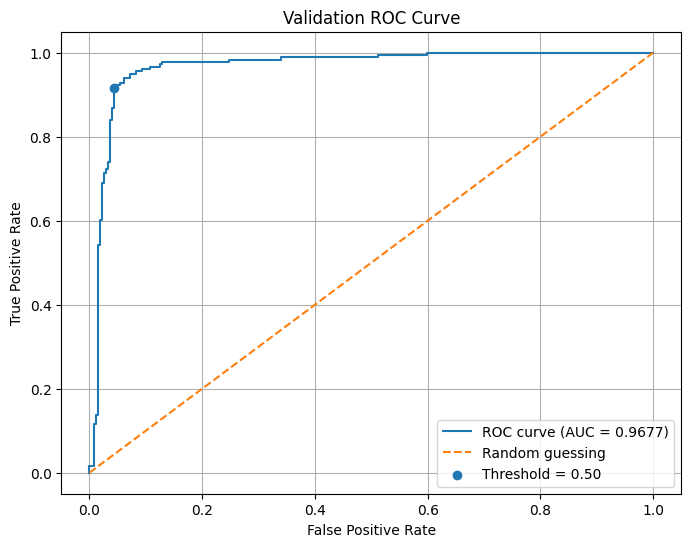

Validation ROC AUC: 0.9677023307392226


In [68]:
# Your code here, as more cells as needed

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_validation, y_prob_validation)

# Compute validation ROC AUC
validation_auc = roc_auc_score(y_validation, y_prob_validation)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {validation_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guessing")

# Mark the operating point at threshold 0.50
plt.scatter(validation_fpr, validation_tpr, label="Threshold = 0.50")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()
plt.grid()
plt.show()
plt.close()

print("Validation ROC AUC:", validation_auc)

In [69]:
# Your answer here, NOT in the next cell

a3a = fpr     # Replace with the FPR values returned by `roc_curve()`

In [70]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3a = {a3a}')

a3a = [0.         0.         0.         0.00716846 0.00716846 0.01075269
 0.01075269 0.01433692 0.01433692 0.01792115 0.01792115 0.02150538
 0.02150538 0.02150538 0.02508961 0.02508961 0.02867384 0.02867384
 0.03225806 0.03225806 0.03584229 0.03584229 0.03942652 0.03942652
 0.04301075 0.04301075 0.04659498 0.04659498 0.05376344 0.05376344
 0.0609319  0.0609319  0.07168459 0.07168459 0.08243728 0.08243728
 0.08960573 0.09318996 0.09318996 0.10752688 0.10752688 0.12544803
 0.12544803 0.12903226 0.12903226 0.24731183 0.24731183 0.34050179
 0.34050179 0.5125448  0.5125448  0.59856631 0.59856631 0.93189964
 0.95698925 0.97491039 0.98207885 1.        ]


In [71]:
# Your answer here, NOT in the next cell

a3b = tpr      # Replace with the TPR values returned by `roc_curve()`

In [72]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3b = {a3b}')

a3b = [0.         0.00552486 0.01657459 0.01657459 0.1160221  0.1160221
 0.13812155 0.13812155 0.54143646 0.54143646 0.60220994 0.60220994
 0.61325967 0.69060773 0.69060773 0.71270718 0.71270718 0.72375691
 0.72375691 0.74033149 0.74033149 0.83977901 0.83977901 0.86740331
 0.86740331 0.91712707 0.91712707 0.92265193 0.92265193 0.9281768
 0.9281768  0.93922652 0.93922652 0.95027624 0.95027624 0.9558011
 0.9558011  0.9558011  0.96132597 0.96132597 0.96685083 0.96685083
 0.97237569 0.97237569 0.97790055 0.97790055 0.98342541 0.98342541
 0.98895028 0.98895028 0.99447514 0.99447514 1.         1.
 1.         1.         1.         1.        ]


In [73]:
# Your answer here, NOT in the next cell

a3c = validation_auc      # Replace with the validation ROC AUC

In [74]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3c = {a3c:.4f}')

a3c = 0.9677


## Problem 4: Select a Decision Threshold

The default threshold of **0.50** is not always the best choice for a classification problem.

For this spam-filtering application, suppose the provider wants to identify at least **95% of actual spam messages**.

Use the **validation set** to select a decision threshold using the following rule:

> Require a **True Positive Rate (TPR) of at least 0.95**.  
> Choose the **highest decision threshold** that satisfies this requirement.

Evaluate thresholds from **0.05 through 0.95 in increments of 0.01**.

For each threshold:

1. Convert `y_prob_validation` into class predictions.
2. Compute the confusion matrix.
3. Compute:
   - Accuracy
   - TPR
   - FPR
4. Store the results in a DataFrame called `threshold_results`.
5. Plot **TPR and FPR versus decision threshold**.
6. Select the threshold using the rule above.

Assign:

- `a4a` = selected threshold
- `a4b` = validation TPR at the selected threshold
- `a4c` = validation FPR at the selected threshold

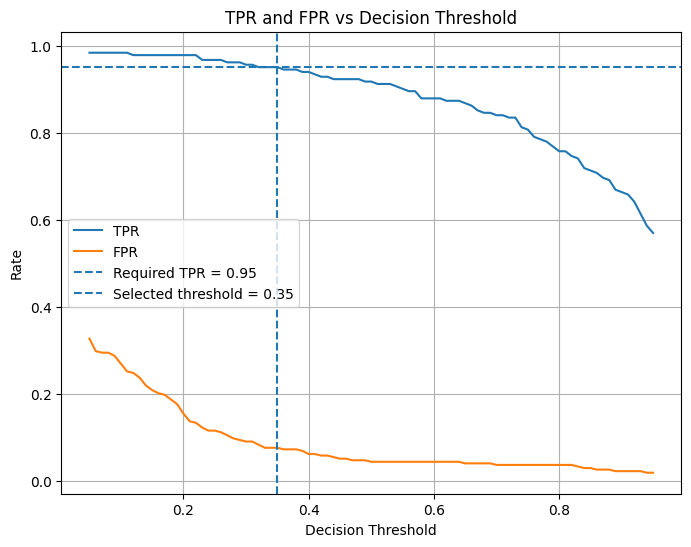

    threshold  accuracy       tpr       fpr
0        0.05  0.795652  0.983425  0.326165
1        0.06  0.813043  0.983425  0.297491
2        0.07  0.815217  0.983425  0.293907
3        0.08  0.815217  0.983425  0.293907
4        0.09  0.819565  0.983425  0.286738
..        ...       ...       ...       ...
86       0.91  0.852174  0.657459  0.021505
87       0.92  0.845652  0.640884  0.021505
88       0.93  0.834783  0.613260  0.021505
89       0.94  0.826087  0.585635  0.017921
90       0.95  0.819565  0.569061  0.017921

[91 rows x 4 columns]
Selected threshold: 0.35000000000000003
Validation TPR: 0.9502762430939227
Validation FPR: 0.07526881720430108


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix

# Your code here, as more cells as needed
# Problem 4: Select a Decision Threshold

# Thresholds from 0.05 through 0.95 in increments of 0.01
thresholds = np.arange(0.05, 0.96, 0.01)

results = []

for threshold in thresholds:
    # Convert probabilities to class predictions
    y_pred = (y_prob_validation >= threshold).astype(int)

    # Compute confusion matrix
    cm = confusion_matrix(y_validation, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Compute metrics
    accuracy = accuracy_score(y_validation, y_pred)
    # Handle division by zero for TPR and FPR if (tp + fn) or (fp + tn) is zero
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    # Store results
    results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "tpr": tpr,
        "fpr": fpr
    })

# Create DataFrame
threshold_results = pd.DataFrame(results)

# Select thresholds with TPR >= 0.95
eligible_thresholds = threshold_results[
    threshold_results["tpr"] >= 0.95
]

# Choose the highest qualifying threshold
# Check if eligible_thresholds is not empty before calling idxmax()
if not eligible_thresholds.empty:
    selected_row = eligible_thresholds.loc[
        eligible_thresholds["threshold"].idxmax()
    ]

    selected_threshold = selected_row["threshold"]
    selected_tpr = selected_row["tpr"]
    selected_fpr = selected_row["fpr"]
else:
    print("No threshold meets the TPR >= 0.95 requirement. Defaulting to 0.50.")
    selected_threshold = 0.50
    # Recalculate metrics for default 0.50 threshold
    y_pred_default = (y_prob_validation >= selected_threshold).astype(int)
    cm_default = confusion_matrix(y_validation, y_pred_default)
    tn_def, fp_def, fn_def, tp_def = cm_default.ravel()
    selected_tpr = tp_def / (tp_def + fn_def) if (tp_def + fn_def) > 0 else 0.0
    selected_fpr = fp_def / (fp_def + tn_def) if (fp_def + tn_def) > 0 else 0.0

# Plot TPR and FPR versus threshold
plt.figure(figsize=(8, 6))
plt.plot(threshold_results["threshold"],
         threshold_results["tpr"],
         label="TPR")
plt.plot(threshold_results["threshold"],
         threshold_results["fpr"],
         label="FPR")
plt.axhline(0.95, linestyle="--", label="Required TPR = 0.95")
plt.axvline(selected_threshold, linestyle="--",
            label=f"Selected threshold = {selected_threshold:.2f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Rate")
plt.title("TPR and FPR vs Decision Threshold")
plt.legend()
plt.grid()
plt.show()
plt.close()

print(threshold_results)
print("Selected threshold:", selected_threshold)
print("Validation TPR:", selected_tpr)
print("Validation FPR:", selected_fpr)

In [76]:
# Your answer here, NOT in the next cell

a4a = selected_threshold      # Replace with an expression that returns the selected threshold

In [77]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4a = {a4a:.2f}')

a4a = 0.35


In [78]:
# Your answer here, NOT in the next cell

a4b = selected_tpr      # Replace with an expression that returns the validation TPR at the selected threshold

In [79]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4b = {a4b:.4f}')

a4b = 0.9503


In [80]:
# Your answer here, NOT in the next cell

a4c = selected_fpr      # Replace with an expression that returns the validation FPR at the selected threshold

In [81]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4c = {a4c:.4f}')

a4c = 0.0753


## Problem 5: Refit the Final Model and Evaluate on the Test Set

In Problem 4, you selected a decision threshold using only the **validation set**.

You will now evaluate the final model on the untouched **test set**.

Follow this workflow:

1. Create a new pipeline containing:
   - `StandardScaler()`
   - `LogisticRegression(max_iter=1000)`
2. Fit the pipeline using the complete **development set**:
   - `X_development`
   - `y_development`
3. Use `predict_proba()` to obtain predicted probabilities for the test set.
4. Apply the **same decision threshold selected in Problem 4**.
   - Do **not** choose a new threshold using the test set.
5. Compute:
   - Accuracy
   - TPR
   - FPR
   - ROC AUC
6. Display the final test confusion matrix.

Assign:

- `a5a` = test ROC AUC
- `a5b` = test TPR
- `a5c` = test FPR

Selected threshold: 0.35000000000000003
Test Accuracy: 0.911062906724512
Test TPR: 0.9120879120879121
Test FPR: 0.08960573476702509
Test ROC AUC: 0.9605340895663477


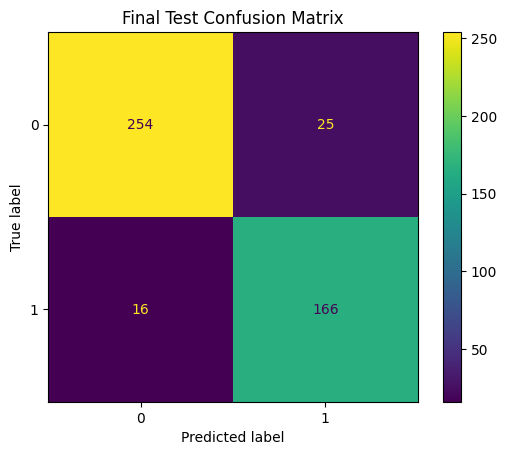

In [82]:
# Your code here, as more cells as needed
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Create the final pipeline
final_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# 2. Fit using the complete development set
final_model.fit(X_development, y_development)

# 3. Get predicted probabilities for the test set
y_prob_test = final_model.predict_proba(X_test)[:, 1]

# 4. Apply the SAME threshold selected in Problem 4
y_pred_test = (y_prob_test >= selected_threshold).astype(int)

# 5. Compute confusion matrix
tn_test, fp_test, fn_test, tp_test = confusion_matrix(
    y_test, y_pred_test
).ravel()

# Compute test metrics
test_accuracy = accuracy_score(y_test, y_pred_test)
test_tpr = tp_test / (tp_test + fn_test)
test_fpr = fp_test / (fp_test + tn_test)
test_auc = roc_auc_score(y_test, y_prob_test)

# Display results
print("Selected threshold:", selected_threshold)
print("Test Accuracy:", test_accuracy)
print("Test TPR:", test_tpr)
print("Test FPR:", test_fpr)
print("Test ROC AUC:", test_auc)

# 6. Display final test confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.title("Final Test Confusion Matrix")
plt.show()
plt.close()

In [83]:
# Your answer here, NOT in the next cell

a5a = test_auc      # Replace with an expression that returns the test ROC AUC

In [84]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a5a = {a5a:.4f}')

a5a = 0.9605


In [85]:
# Your answer here, NOT in the next cell

a5b = test_tpr      # Replace with an expression that returns the test TPR

In [86]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a5b = {a5b:.4f}')

a5b = 0.9121


In [87]:
# Your answer here, NOT in the next cell

a5c = test_fpr      # Replace with an expression that returns the test FPR

In [88]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a5c = {a5c:.4f}')

a5c = 0.0896


## Problem 6: Multiple Choice

For each question, assign the number of the best answer to the corresponding variable.

Each question is worth **2 points**.

### Part A Graded Answer: Logistic Regression Output

A logistic regression model first computes the linear value

$$
z = \beta_0 + \beta_1x_1 + \cdots + \beta_mx_m.
$$

Why is the sigmoid function then applied to $z$?

1. To make the relationship between the predictors and $z$ linear
2. To transform $z$ into a value between 0 and 1 that can be interpreted as a probability
3. To choose the decision threshold that maximizes accuracy
4. To standardize the predictor variables

In [89]:
# Your answer here, NOT in the next cell

a6a = 2      # Replace with the number of the best answer

In [90]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6a = {a6a}')

a6a = 2


### Part B Graded Answer: Cross-Entropy Loss

Suppose an email is actually spam, so $y=1$.

Which predicted probability for spam would produce the **largest cross-entropy loss**?

1. 0.99
2. 0.80
3. 0.50
4. 0.01

In [91]:
# Your answer here, NOT in the next cell

a6b = 4      # Replace with the number of the best answer

In [92]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6b = {a6b}')

a6b = 4


### Part C Graded Answer: Decision Thresholds

Suppose the decision threshold for classifying an email as spam is lowered from 0.50 to 0.30.

What should generally happen?

1. Both TPR and FPR decrease
2. TPR increases and FPR decreases
3. TPR decreases and FPR increases
4. Both TPR and FPR increase

In [93]:
# Your answer here, NOT in the next cell

a6c = 4     # Replace with the number of the best answer

In [94]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6c = {a6c}')

a6c = 4


### Part D Graded Answer: ROC AUC

Suppose you change the decision threshold used by a trained logistic regression model from 0.50 to 0.35.

Which statement is correct?

1. The ROC AUC must increase because TPR increases
2. The ROC AUC must decrease because FPR increases
3. The operating point on the ROC curve changes, but the ROC AUC does not change
4. Both the ROC curve and the ROC AUC must be recomputed from the new class predictions

In [95]:
# Your answer here, NOT in the next cell

a6d = 3      # Replace with the number of the best answer

In [96]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6d = {a6d}')

a6d = 3


### Part E Graded Answer: Validation and Test Performance

In Problem 4, a decision threshold was selected because it achieved a validation TPR of at least 0.95.

After the final model was refit on the complete development set, its TPR on the untouched test set was lower than 0.95.

What is the best interpretation?

1. The threshold-selection procedure was incorrect because the test TPR must also be at least 0.95
2. The model should now be retuned using the test set until the test TPR reaches 0.95
3. The difference is expected because validation and test performance are estimates based on different samples
4. The lower test TPR proves that logistic regression is overfitting

In [97]:
# Your answer here, NOT in the next cell

a6e = 3      # Replace with the number of the best answer

In [98]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6e = {a6e}')

a6e = 3


## Problem 7: Discussion

Throughout this homework, you trained a logistic regression model to identify spam and then used the **validation set** to select a decision threshold that achieved a TPR of at least 0.95 by choosing the highest threshold that satisfied this requirement.

In one paragraph of approximately **5–7 sentences**, explain:

- how and why the selected threshold differed from the default threshold of 0.50, including the resulting tradeoff between TPR and FPR;
- why the threshold was selected using the validation set rather than the test set, and why the final test TPR did not have to remain at or above 0.95;
- what the final test results suggest about how well the modeling process generalized to previously unseen email.

Refer to at least **two specific numerical results** from your notebook.

In [99]:
# Your answer here, NOT in the next cell

a7 = """
The selected decision threshold was 0.35, which was lower than the default threshold of 0.50 because the goal was to achieve a validation TPR of at least 0.95. Lowering the threshold made the model more likely to classify emails as spam, boosting both the TPR and the FPR; at the selected threshold, the validation TPR was 0.9503 and the validation FPR was 0.0753. The threshold was chosen using the validation set rather than the test set so that the test set remained untouched and could provide an unbiased final evaluation of the modeling procedure. The final test TPR did not need to remain at or above 0.95 because the 0.95 requirement was used to select the threshold on the validation sample, although performance on a separate test sample can vary. On the test set, the model achieved a TPR of 0.9121, an FPR of 0.0896, an accuracy of 0.9111, and a ROC AUC of 0.9605. Overall, the test findings indicate that the model generalized well to previously unseen email, although its test TPR was slightly lower than the validation TPR.
"""

In [100]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print("a7 =")
print(a7)

a7 =

The selected decision threshold was 0.35, which was lower than the default threshold of 0.50 because the goal was to achieve a validation TPR of at least 0.95. Lowering the threshold made the model more likely to classify emails as spam, boosting both the TPR and the FPR; at the selected threshold, the validation TPR was 0.9503 and the validation FPR was 0.0753. The threshold was chosen using the validation set rather than the test set so that the test set remained untouched and could provide an unbiased final evaluation of the modeling procedure. The final test TPR did not need to remain at or above 0.95 because the 0.95 requirement was used to select the threshold on the validation sample, although performance on a separate test sample can vary. On the test set, the model achieved a TPR of 0.9121, an FPR of 0.0896, an accuracy of 0.9111, and a ROC AUC of 0.9605. Overall, the test findings indicate that the model generalized well to previously unseen email, although its test TPR